# Imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import json
import math
import sys

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/k2-19-project/data


In [3]:
### Switches 
### switch to mask out transits
mask_transits = False

### switch to use original or forked batman
greg_batman = True

In [4]:
### Define data directory
# data_dir = "/Users/pentrican10/Projects/Data/k2-19-data"

TESS_offset = 2457000
petigura_offset = 2454833

### set range for search: [#hours] * [days per hour]
ttv_hour = 2* 0.0416667 # 1 hour to days

In [5]:
T14_b = 3.237 * 0.0416667
T14_c = 3.823 * 0.0416667

In [6]:
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

def convert_time_p2t(times):
    ### TESS offset 
    BTJD = times + petigura_offset
    new_time = BTJD - TESS_offset
    return new_time

# Predicted times from Petigura 
within TESS baseline

In [7]:
### Predicted times from Petigura2020
file_petigura_predicted_time = 'ajab5220t4_mrt.txt'
def read_table(file_name):
    ### path to table - Petigura et al 2020
    file_path = os.path.join(data_dir, file_name)

    ### Define the column names 
    columns = ["Planet", "Transit","Date", "Tc_pred", "e_Tc_pred"]

    ### Read the text file, specifying space as the delimiter, skipping model_guess_omc rows
    df = pd.read_csv(file_path, delim_whitespace=True, skiprows=17, names=columns)

    ### Remove NaN values
    df = df.dropna()
    return df

df_petigura_mod = read_table(file_petigura_predicted_time)

### separate by planet
df_petigura_b = df_petigura_mod[df_petigura_mod["Planet"] == 'b']
print(df_petigura_b)
df_petigura_c = df_petigura_mod[df_petigura_mod["Planet"] == 'c']

# Filter for times < 5500 within TESS baseline
df_petigura_b = df_petigura_b[df_petigura_b["Tc_pred"] < 5500]
df_petigura_c = df_petigura_c[df_petigura_c["Tc_pred"] < 5500]

     Planet  Transit        Date    Tc_pred  e_Tc_pred
0         b        0  2014-06-04  1980.3840     0.0002
2         b        1  2014-06-12  1988.3041     0.0002
4         b        2  2014-06-20  1996.2220     0.0002
5         b        3  2014-06-28  2004.1406     0.0002
7         b        4  2014-07-06  2012.0614     0.0001
...     ...      ...         ...        ...        ...
1189      b      714  2029-11-28  7635.6831     0.0496
1191      b      715  2029-12-06  7643.6031     0.0480
1193      b      716  2029-12-14  7651.5243     0.0468
1194      b      717  2029-12-21  7659.4466     0.0446
1196      b      718  2029-12-29  7667.3662     0.0434

[719 rows x 5 columns]


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_92544/2425245993.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, skiprows=17, names=columns)


In [8]:
### Extract predicted time data
ind_petigura_b = df_petigura_b["Transit"]
ind_petigura_c = df_petigura_c["Transit"]

### convert times to TESS offset
t_petigura_b = convert_time_p2t(df_petigura_b["Tc_pred"])
t_petigura_c = convert_time_p2t(df_petigura_c["Tc_pred"])

t_err_petigura_b = df_petigura_b["e_Tc_pred"]
t_err_petigura_c = df_petigura_c["e_Tc_pred"]


# Get light curve

In [9]:
# Download the light curve data
lc = lk.search_lightcurve("K2-19",author = 'SPOC').download_all()
print(lc)


LightCurveCollection of 3 objects:
    0: <TessLightCurve LABEL="TIC 281885301" SECTOR=45 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 281885301" SECTOR=46 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 281885301" SECTOR=72 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


In [61]:
print(lc.meta)

OrderedDict({'INHERIT': True, 'EXTNAME': 'PRIMARY', 'EXTVER': 1, 'SIMDATA': False, 'TELESCOP': 'TESS', 'INSTRUME': 'TESS Photometer', 'OBJECT': 'TIC 281885301', 'TICID': 281885301, 'RADESYS': 'ICRS', 'RA_OBJ': 174.960335193759, 'DEC_OBJ': 0.603577030543463, 'EQUINOX': 2000.0, 'EXPOSURE': 20.105438590631, 'TIMEREF': 'SOLARSYSTEM', 'TASSIGN': 'SPACECRAFT', 'TIMESYS': 'TDB', 'BJDREFI': 2457000, 'BJDREFF': 0.0, 'TIMEUNIT': 'd', 'TELAPSE': 25.38565478615, 'LIVETIME': 20.10543859063052, 'TSTART': 3260.179718244801, 'TSTOP': 3285.565372799469, 'DATE-OBS': '2023-11-11T16:17:38.472', 'DATE-END': '2023-12-07T01:32:59.026', 'DEADC': 0.792, 'TIMEPIXR': 0.5, 'TIERRELA': 1.16e-05, 'INT_TIME': 1.98, 'READTIME': 0.02, 'FRAMETIM': 2.0, 'NUM_FRM': 60, 'TIMEDEL': 0.0013888888888889, 'BACKAPP': True, 'DEADAPP': True, 'VIGNAPP': True, 'GAINA': 5.300000190734863, 'GAINB': 5.179999828338623, 'GAINC': 5.269999980926514, 'GAIND': 5.190000057220459, 'READNOIA': 10.017000198364258, 'READNOIB': 7.407399654388428,

In [10]:
### Download the light curve data
lc = lc.stitch()
if mask_transits == True:
    ### mask transit times before flattening
    #transit_times = [4697.28834658, 4713.12428017, 4721.03972171, 4728.96021376, 4736.88070581, 4744.79614735, 5433.87895563, 5449.71993973]
    transit_times = [4697.28834658, 4713.12933068, 4721.03972171, 4728.96021376, 4736.88070581, 4744.80119786, 5433.87895563, 5449.71993973]
    masked_lc = lc

    times = convert_time_t2p(masked_lc.time.value)

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_times:
        mask |= (times > (transit_time - T14_b/2)) & (times < (transit_time + T14_b/2))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=901, mask=mask).remove_outliers()
    lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    lc = lc.flatten(window_length=901).remove_outliers()


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


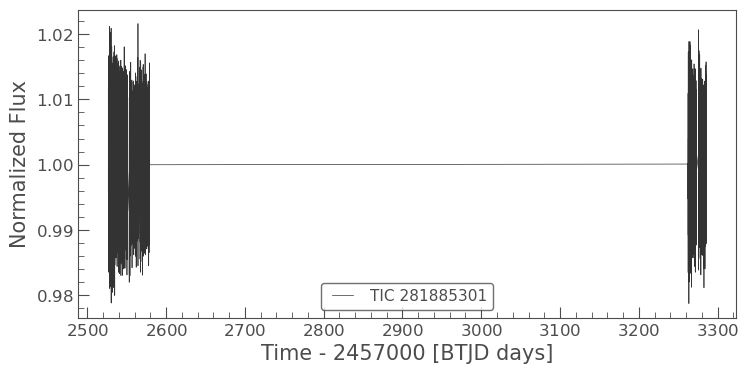

In [60]:
lc.plot()
plt.show()

# Petigura prediction times

In [12]:
window = 1 # days around transit time

In [13]:
lc_sections_b = []  # stores (lightcurve, t_pred, transit_num)
lc_sections_c = []
transit_guess_pet_b = []
transit_guess_pet_c = []

# Store for planet b
for t_pred, transit_num in zip(t_petigura_b, ind_petigura_b):
    mask = (lc.time.value > t_pred - window) & (lc.time.value < t_pred + window)
    lc_cut = lc[mask]
    if len(lc_cut.time) > 0:
        lc_sections_b.append((lc_cut, t_pred, transit_num))
        transit_guess_pet_b.append(t_pred)

# Store for planet c
for t_pred, transit_num in zip(t_petigura_c, ind_petigura_c):
    mask = (lc.time.value > t_pred - window) & (lc.time.value < t_pred + window)
    lc_cut = lc[mask]
    if len(lc_cut.time) > 0:
        lc_sections_c.append((lc_cut, t_pred, transit_num))
        transit_guess_pet_c.append(t_pred)


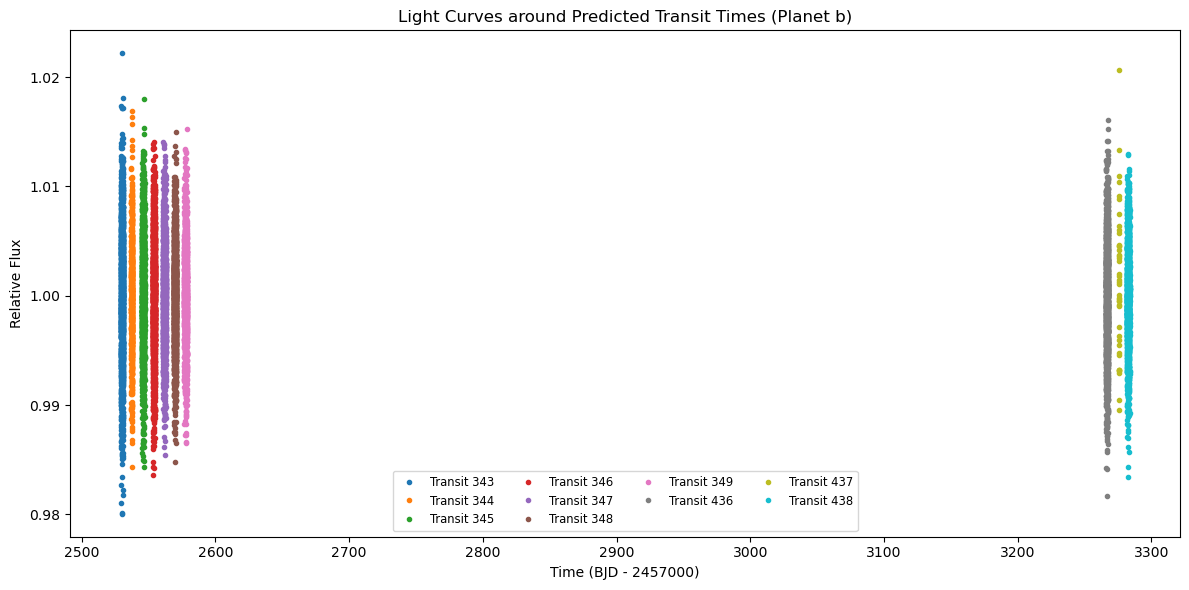

In [14]:
# Plot for planet b
fig_b, ax_b = plt.subplots(figsize=(12, 6))
ax_b.set_title('Light Curves around Predicted Transit Times (Planet b)')
ax_b.set_xlabel('Time (BJD - 2457000)')
ax_b.set_ylabel('Relative Flux')

for i, t_pred in enumerate(t_petigura_b):
    # Select a time window around the predicted transit time
    mask = (lc.time.value > t_pred - window) & (lc.time.value < t_pred + window)
    lc_cut = lc[mask]
    
    if len(lc_cut.time) > 0:
        ax_b.plot(lc_cut.time.value, lc_cut.flux.value, '.', label=f'Transit {int(ind_petigura_b.iloc[i])}')
    
ax_b.legend(fontsize='small', ncol=4)
plt.tight_layout()
plt.show()


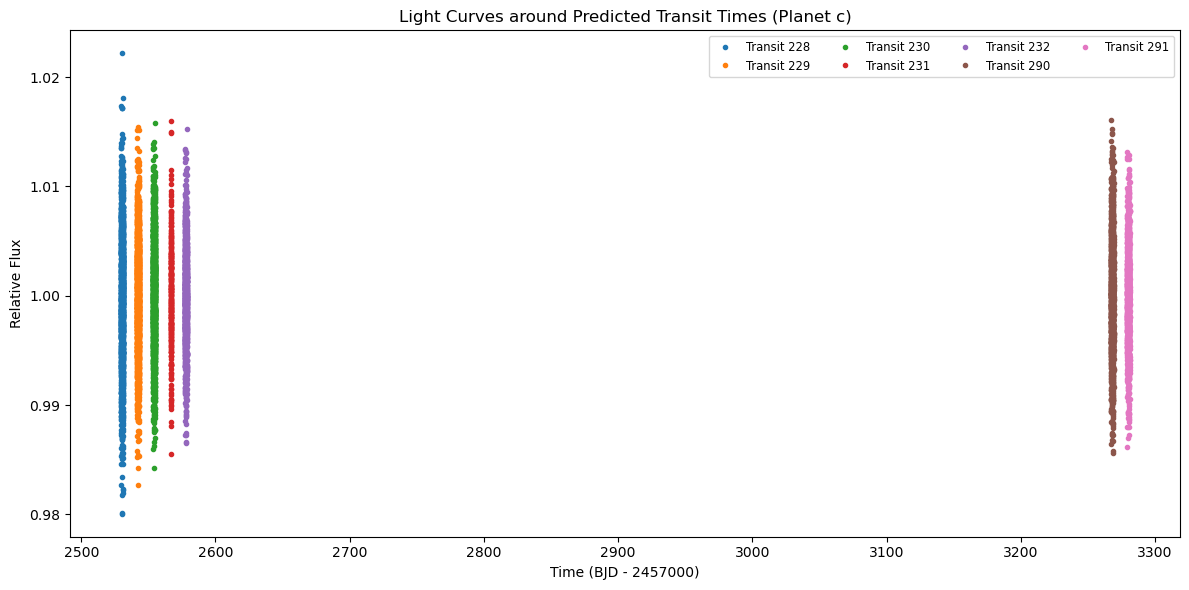

In [15]:
# Plot for planet c
fig_c, ax_c = plt.subplots(figsize=(12, 6))
ax_c.set_title('Light Curves around Predicted Transit Times (Planet c)')
ax_c.set_xlabel('Time (BJD - 2457000)')
ax_c.set_ylabel('Relative Flux')

for i, t_pred in enumerate(t_petigura_c):
    mask = (lc.time.value > t_pred - window) & (lc.time.value < t_pred + window)
    lc_cut = lc[mask]
    
    if len(lc_cut.time) > 0:
        ax_c.plot(lc_cut.time.value, lc_cut.flux.value, '.', label=f'Transit {int(ind_petigura_c.iloc[i])}')
    
ax_c.legend(fontsize='small', ncol=4)
plt.tight_layout()
plt.show()

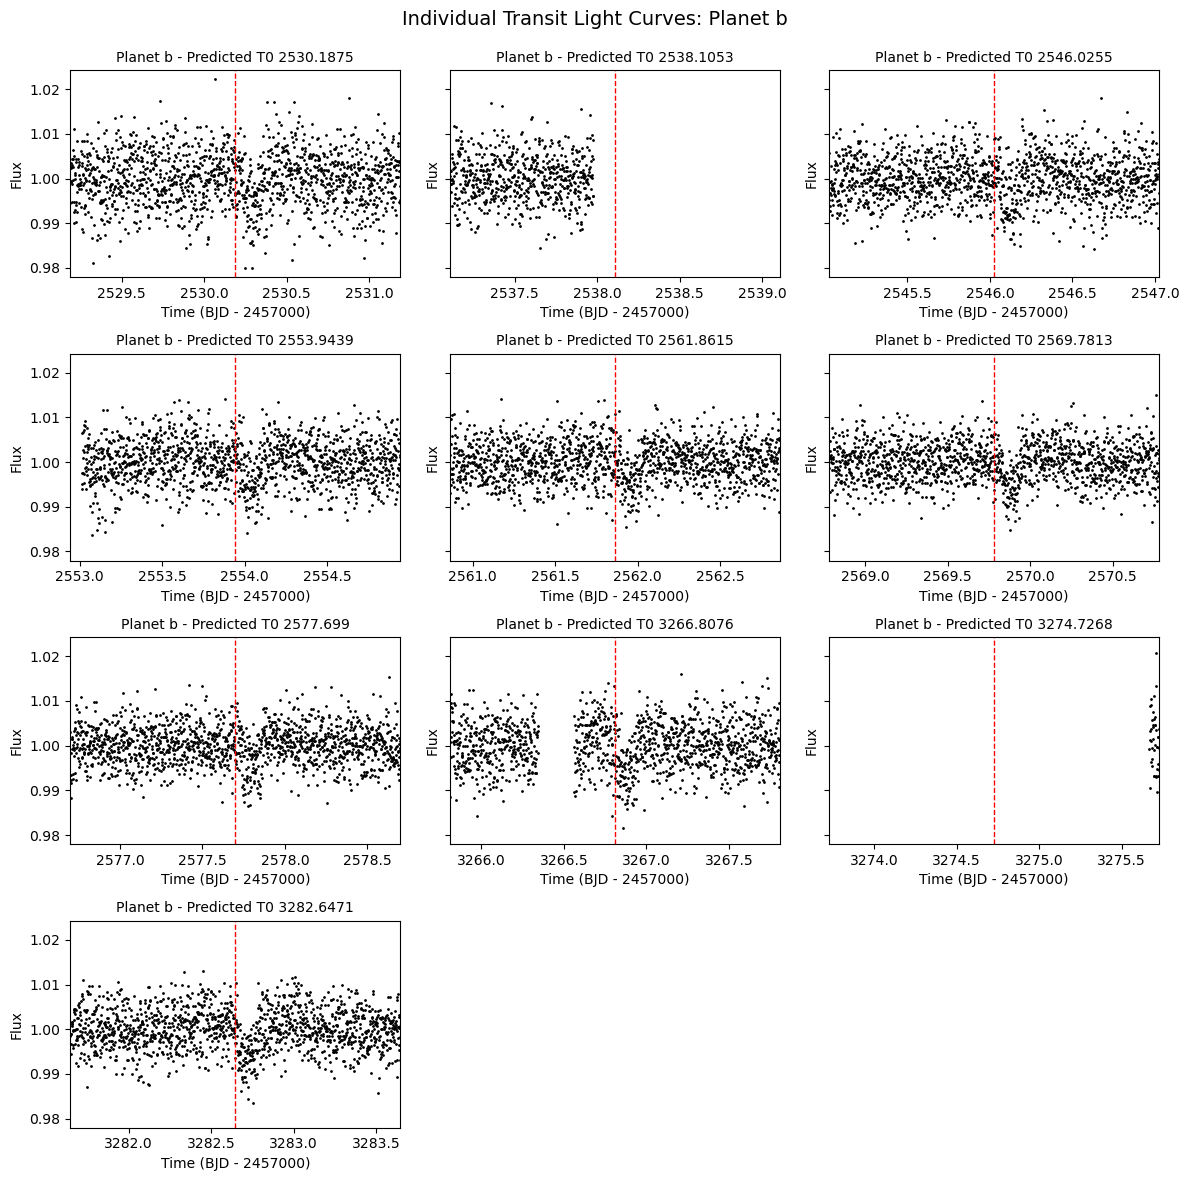

In [16]:
n_b = len(lc_sections_b)
cols = 3
rows = int(np.ceil(n_b / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, (lc_cut, t_pred, transit_num) in enumerate(lc_sections_b):
    axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
    axes[i].axvline(t_pred, color='red', linestyle='--', lw=1)
    axes[i].set_title(f'Planet b - Predicted T0 {round(t_pred,4)}', fontsize=10)
    axes[i].set_xlim(t_pred - window, t_pred + window)
    axes[i].set_xlabel('Time (BJD - 2457000)')
    axes[i].set_ylabel('Flux')

# Clean unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Individual Transit Light Curves: Planet b', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

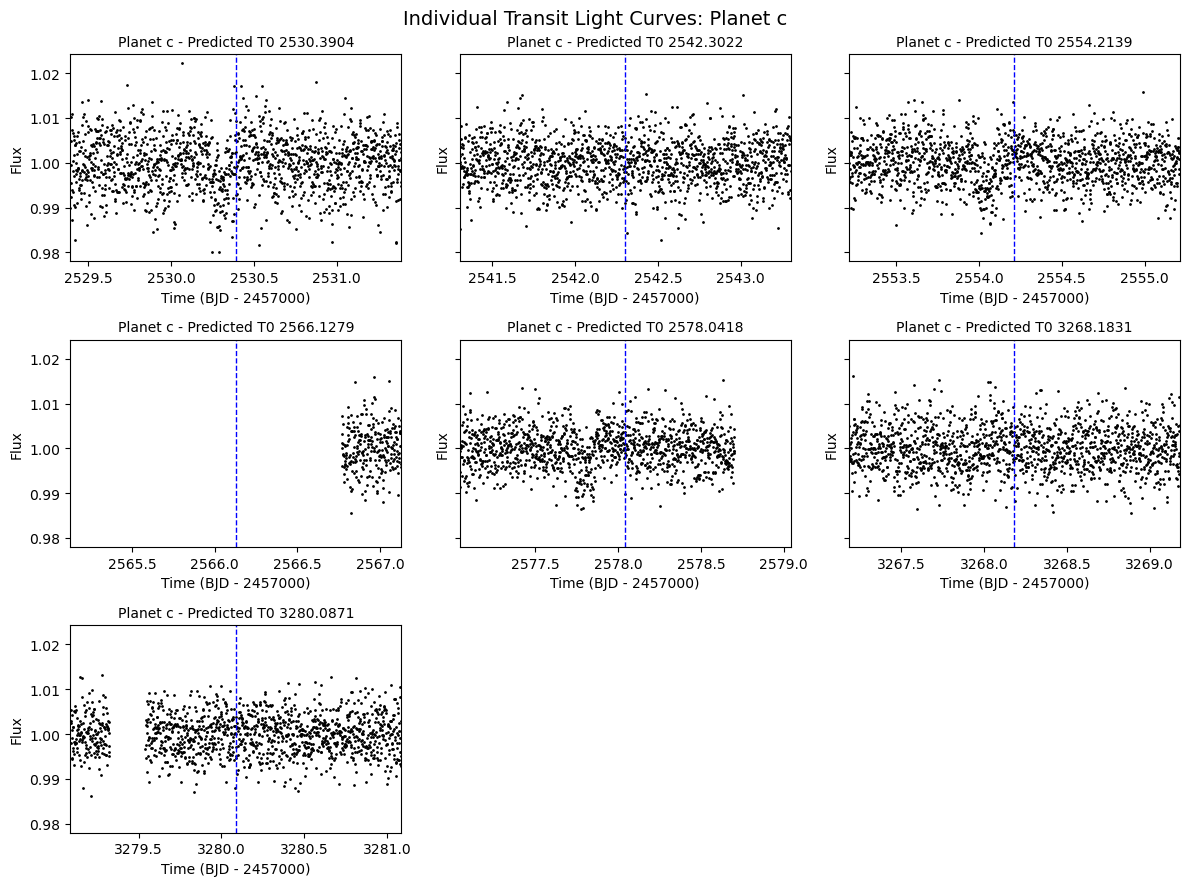

In [17]:
n_c = len(lc_sections_c)
cols = 3
rows = int(np.ceil(n_c / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, (lc_cut, t_pred, transit_num) in enumerate(lc_sections_c):
    axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
    axes[i].axvline(t_pred, color='blue', linestyle='--', lw=1)
    axes[i].set_title(f'Planet c - Predicted T0 {round(t_pred,4)}', fontsize=10)
    axes[i].set_xlim(t_pred - window, t_pred + window)
    axes[i].set_xlabel('Time (BJD - 2457000)')
    axes[i].set_ylabel('Flux')

# Clean unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Individual Transit Light Curves: Planet c', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# jnkep Predicted times 

In [18]:
# Load the data from the JSON file
with open("data/jnkep_mcmc_data.json", "r") as f:
    data_mcmc = json.load(f)
# Access values just like a dictionary
t_jnkep_b = np.array(data_mcmc["jnkep_mcmc_times"]["b"])
t_jnkep_c = np.array(data_mcmc["jnkep_mcmc_times"]["c"])
### convert to TESS time
t_jnkep_b = convert_time_p2t(t_jnkep_b)
t_jnkep_c = convert_time_p2t(t_jnkep_c)


t_jnkep_err_b = data_mcmc["jnkep_mcmc_times_err"]["b"]
t_jnkep_err_c = data_mcmc["jnkep_mcmc_times_err"]["c"]


In [19]:
# Store light curve cutouts + metadata for JNKEP predictions
lc_sections_jnkep_b = []
lc_sections_jnkep_c = []
transit_guess_jnkep_b = []
transit_guess_jnkep_c = []
ind = []
# Planet b (using index as label)
for i, t_pred in enumerate(t_jnkep_b):
    mask = (lc.time.value > t_pred - window) & (lc.time.value < t_pred + window)
    lc_cut = lc[mask]
    if len(lc_cut.time) > 1000:
        lc_sections_jnkep_b.append((lc_cut, t_pred, i))
        transit_guess_jnkep_b.append(t_pred)

# Planet c
for i, t_pred in enumerate(t_jnkep_c):
    mask = (lc.time.value > t_pred - window) & (lc.time.value < t_pred + window)
    lc_cut = lc[mask]
    if len(lc_cut.time) > 1000:
        lc_sections_jnkep_c.append((lc_cut, t_pred, i))
        transit_guess_jnkep_c.append(t_pred)
        ind.append(i)

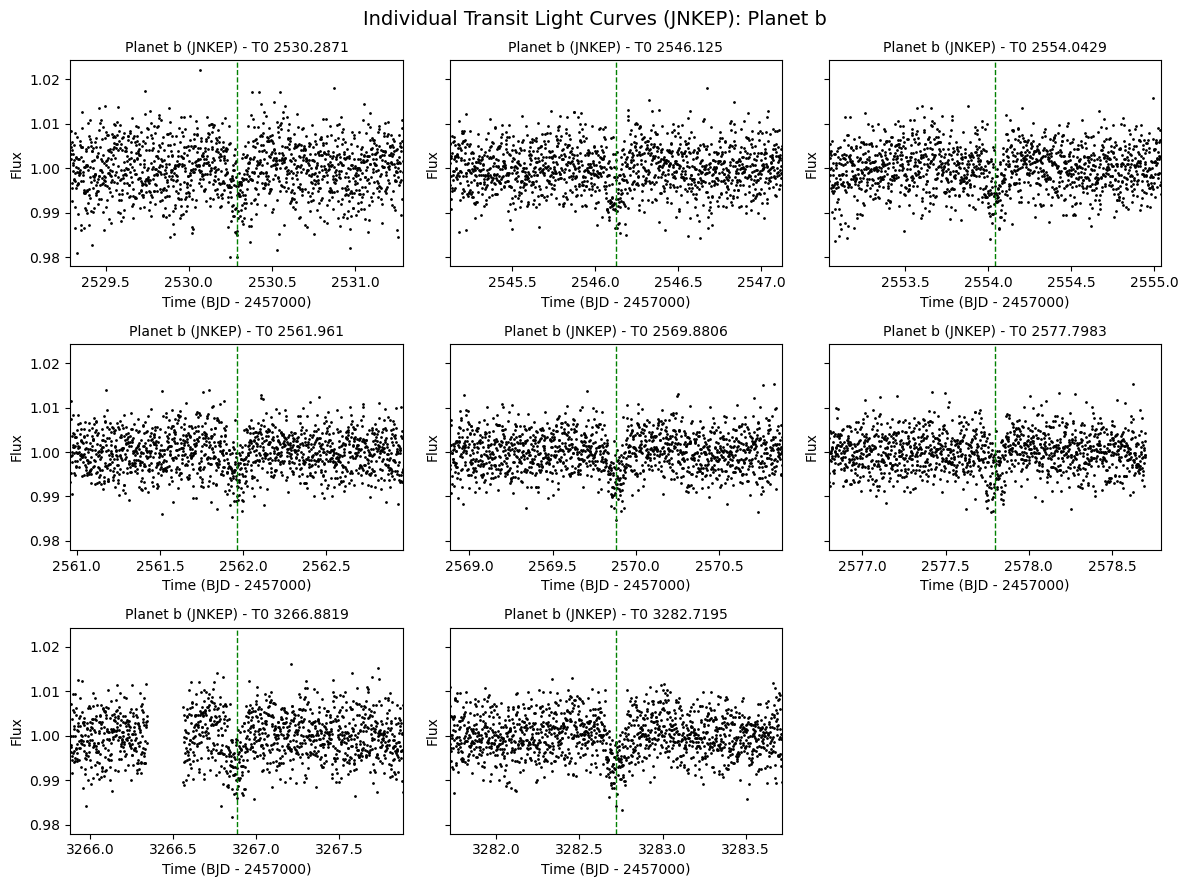

In [20]:
n_b = len(lc_sections_jnkep_b)
cols = 3
rows = int(np.ceil(n_b / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, (lc_cut, t_pred, idx) in enumerate(lc_sections_jnkep_b):
    axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
    axes[i].axvline(t_pred, color='green', linestyle='--', lw=1)
    axes[i].set_title(f'Planet b (JNKEP) - T0 {round(t_pred,4)}', fontsize=10)
    axes[i].set_xlim(t_pred - window, t_pred + window)
    axes[i].set_xlabel('Time (BJD - 2457000)')
    axes[i].set_ylabel('Flux')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Individual Transit Light Curves (JNKEP): Planet b', fontsize=14)
plt.tight_layout()
# plt.subplots_adjust(top=0.93)
plt.show()


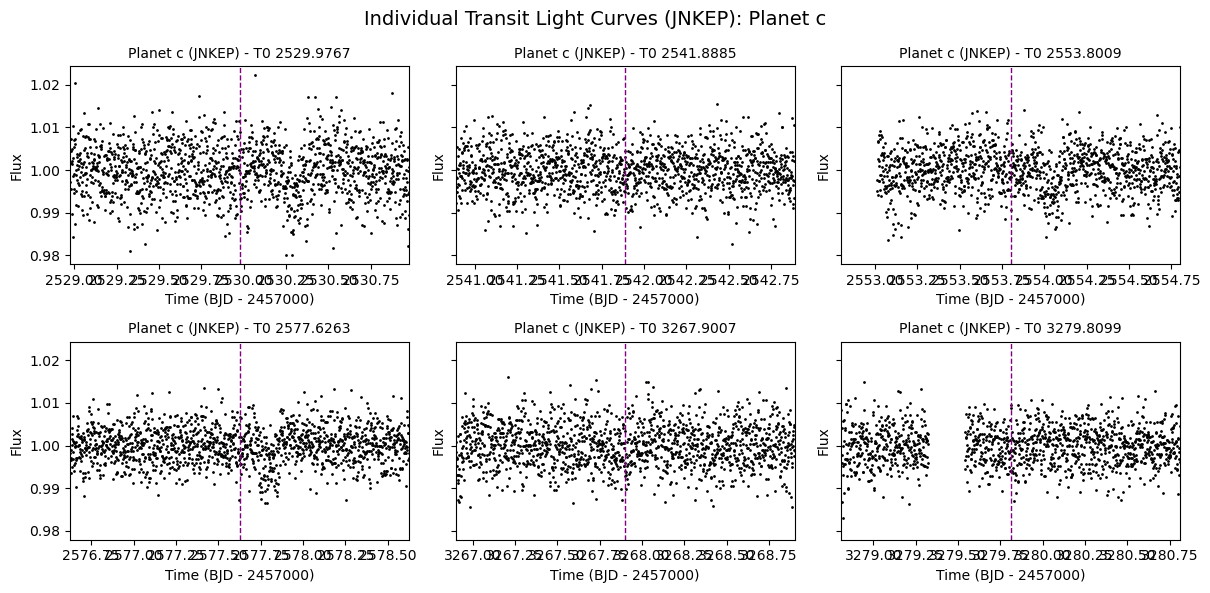

In [21]:
n_c = len(lc_sections_jnkep_c)
cols = 3
rows = int(np.ceil(n_c / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, (lc_cut, t_pred, idx) in enumerate(lc_sections_jnkep_c):
    axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
    axes[i].axvline(t_pred, color='purple', linestyle='--', lw=1)
    axes[i].set_title(f'Planet c (JNKEP) - T0 {round(t_pred,4)}', fontsize=10)
    axes[i].set_xlim(t_pred - window, t_pred + window)
    axes[i].set_xlabel('Time (BJD - 2457000)')
    axes[i].set_ylabel('Flux')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Individual Transit Light Curves (JNKEP): Planet c', fontsize=14)
plt.tight_layout()
# plt.subplots_adjust(top=0.93)
plt.show()


# Combined figure

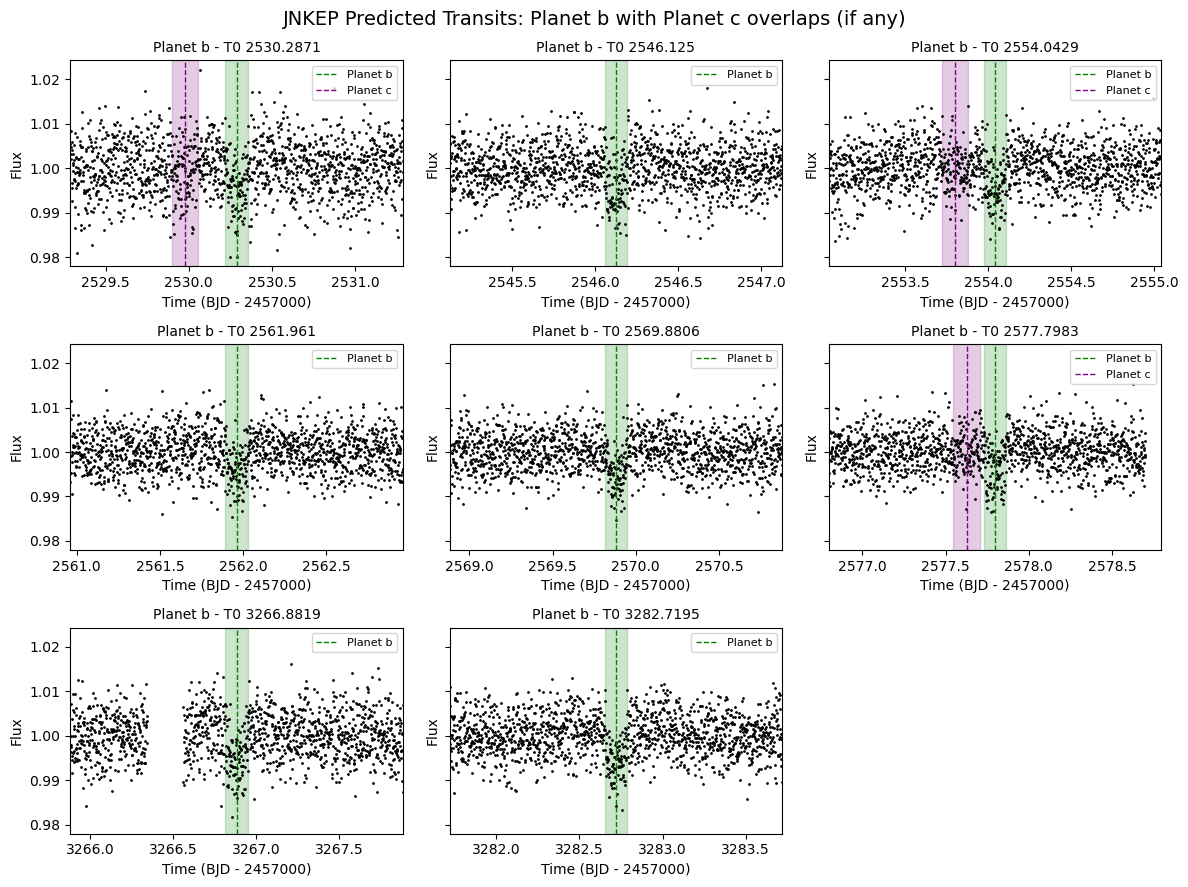

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Extract all t_pred for planet c
t_preds_c = np.array([t_pred_c for _, t_pred_c, _ in lc_sections_jnkep_c])

n_b = len(lc_sections_jnkep_b)
cols = 3
rows = int(np.ceil(n_b / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, (lc_cut, t_pred_b, idx) in enumerate(lc_sections_jnkep_b):
    ax = axes[i]

    # Plot the light curve
    ax.plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)

    # Planet b: transit center and duration
    ax.axvline(t_pred_b, color='green', linestyle='--', lw=1, label='Planet b')
    ax.axvspan(t_pred_b - T14_b/2, t_pred_b + T14_b/2, color='green', alpha=0.2)

    # Planet c: check if any t_pred_c falls within b's window
    in_window = (t_preds_c > t_pred_b - window) & (t_preds_c < t_pred_b + window)
    for t_c in t_preds_c[in_window]:
        ax.axvline(t_c, color='purple', linestyle='--', lw=1, label='Planet c')
        ax.axvspan(t_c - T14_c/2, t_c + T14_c/2, color='purple', alpha=0.2)

    ax.set_title(f'Planet b - T0 {round(t_pred_b, 4)}', fontsize=10)
    ax.set_xlim(t_pred_b - window, t_pred_b + window)
    ax.set_xlabel('Time (BJD - 2457000)')
    ax.set_ylabel('Flux')

    # Optional: unique legend per subplot
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='upper right')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('JNKEP Predicted Transits: Planet b with Planet c overlaps (if any)', fontsize=14)
plt.tight_layout()
# plt.subplots_adjust(top=0.93)
plt.show()

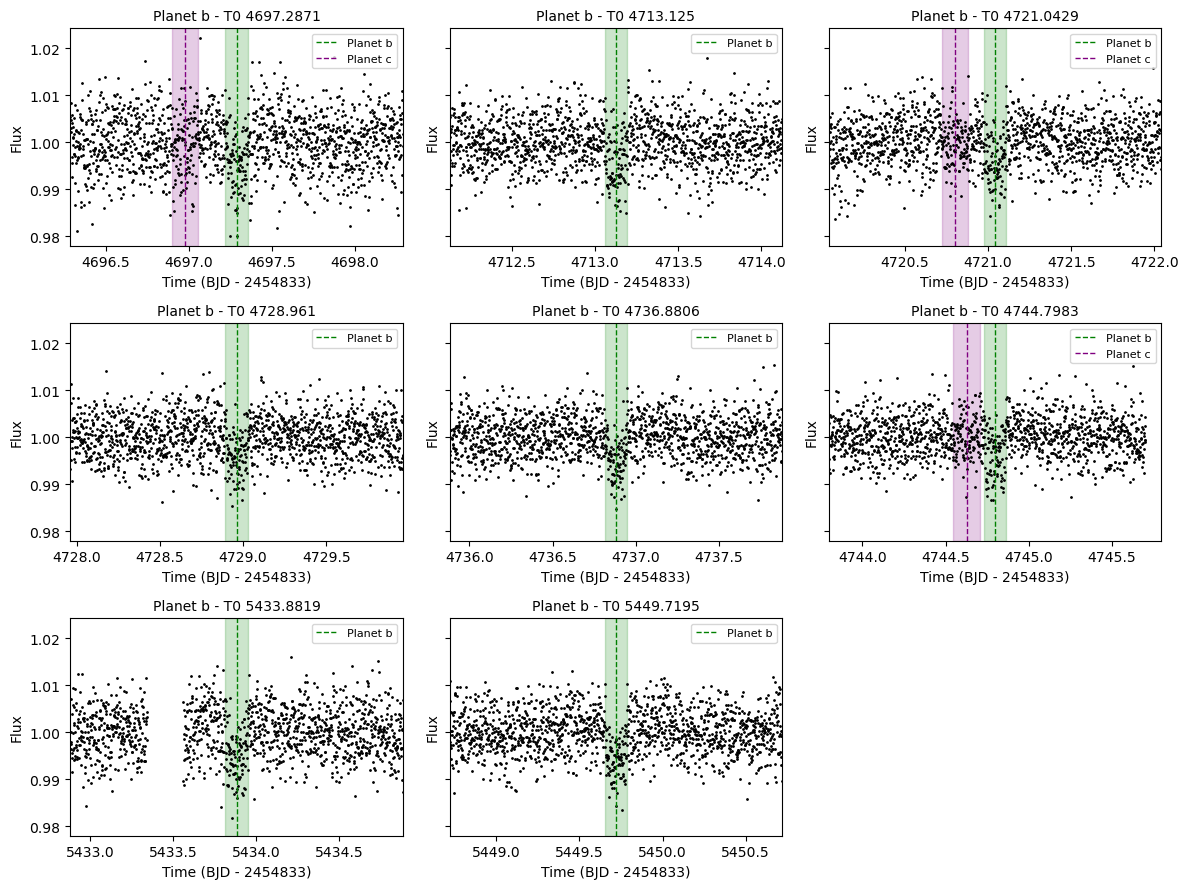

In [23]:
# Convert all planet c predicted times once outside the loop
t_preds_c_orig = np.array([t_pred_c for _, t_pred_c, _ in lc_sections_jnkep_c])
t_preds_c = convert_time_t2p(t_preds_c_orig)  # Apply conversion

n_b = len(lc_sections_jnkep_b)
cols = 3
rows = int(np.ceil(n_b / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, (lc_cut, t_pred_b_orig, idx) in enumerate(lc_sections_jnkep_b):
    ax = axes[i]

    # Convert light curve time and planet b predicted time
    time_converted = convert_time_t2p(lc_cut.time.value)
    t_pred_b = convert_time_t2p(t_pred_b_orig)

    # Plot the converted light curve
    ax.plot(time_converted, lc_cut.flux.value, 'k.', markersize=2)

    # Planet b: transit center and duration
    ax.axvline(t_pred_b, color='green', linestyle='--', lw=1, label='Planet b')
    ax.axvspan(t_pred_b - T14_b/2, t_pred_b + T14_b/2, color='green', alpha=0.2)

    # Planet c: check if any t_pred_c falls within b's window
    in_window = (t_preds_c > t_pred_b - window) & (t_preds_c < t_pred_b + window)
    for t_c in t_preds_c[in_window]:
        ax.axvline(t_c, color='purple', linestyle='--', lw=1, label='Planet c')
        ax.axvspan(t_c - T14_c/2, t_c + T14_c/2, color='purple', alpha=0.2)

    ax.set_title(f'Planet b - T0 {round(t_pred_b, 4)}', fontsize=10)
    ax.set_xlim(t_pred_b - window, t_pred_b + window)
    ax.set_xlabel(f'Time (BJD - {petigura_offset})')
    ax.set_ylabel('Flux')

    # Optional: unique legend per subplot
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='upper right')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle('JNKEP Predicted Transit Times: Planet b (+ Planet c if in window)', fontsize=14)
plt.tight_layout()
plt.show()


In [24]:
print('petigura guess times')
print(transit_guess_pet_b)
print(transit_guess_pet_c)

print('jnkep guess times')
print(transit_guess_jnkep_b)
print(transit_guess_jnkep_c)


petigura guess times
[2530.1875, 2538.1052999999374, 2546.025499999989, 2553.9438999998383, 2561.8615000001155, 2569.781299999915, 2577.6990000000224, 3266.807599999942, 3274.7267999998294, 3282.6471000001766]
[2530.3903999999166, 2542.302199999802, 2554.213899999857, 2566.127900000196, 2578.0417999997735, 3268.183100000024, 3280.0871000001207]
jnkep guess times
[2530.287050227169, 2546.1250185910612, 2554.0428536571562, 2561.9610104146414, 2569.880562095437, 2577.7983084646985, 3266.881909671705, 3282.71947990451]
[2529.9767496790737, 2541.888493819628, 2553.8008535872214, 2577.626305473037, 3267.900701981969, 3279.809936615173]


In [25]:
use_pet_prediction = True

if use_pet_prediction == True:
    transit_guess_b = transit_guess_pet_b
    transit_guess_c = transit_guess_pet_c
else:
    transit_guess_b = transit_guess_jnkep_b
    transit_guess_c = transit_guess_jnkep_c
    

# Mask out transit guesses

In [26]:
mask_transits = True

In [27]:
### Download the light curve data
lc = lk.search_lightcurve("K2-19",author = 'SPOC').download_all()
lc = lc.stitch()
if mask_transits == True:
    mask_scale = 4
    ### mask transit times before flattening
    masked_lc = lc

    # times = convert_time_t2p(masked_lc.time.value)
    times = masked_lc.time.value

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_guess_b:
        mask |= (times > (transit_time - T14_b/2*mask_scale)) & (times < (transit_time + T14_b/2*mask_scale))

    for transit_time in transit_guess_c:
        mask |= (times > (transit_time - T14_c/2*mask_scale)) & (times < (transit_time + T14_c/2*mask_scale))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=901, mask=mask).remove_outliers()
    lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    lc = lc.flatten(window_length=901).remove_outliers()


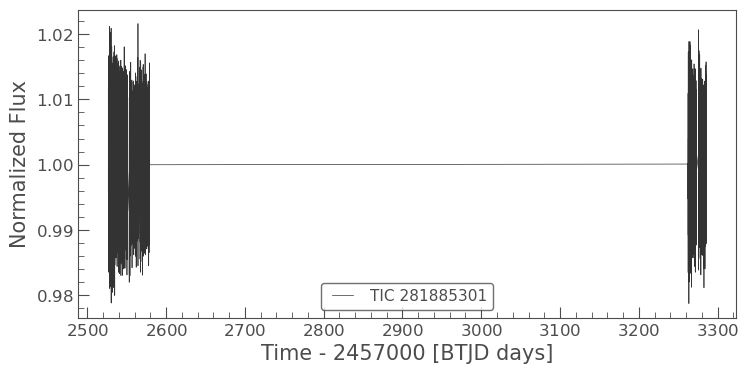

In [28]:
lc.plot()
plt.show()

In [29]:
### data from lightcurve 
time = np.array(lc.time.value)
flux=np.array(lc.flux)
flux_err = np.array(lc.flux_err)

# time = convert_time_t2p(time_tess)

# Fit times

In [30]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

### Chi sq fit

In [31]:
def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        # ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
       
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        # err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # Find the intersection using root_scalar
        intersections = []
        for k in range(len(tc1) - 1):
            if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
                sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
                if sol.converged:
                    intersections.append((sol.root - min_chi_time))
        errors.append(intersections)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, errors

### Single Transits

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(time, flux, flux_err, transit_times, per, rp, b, T14, u1, u2, buffer = 0.1, offset=TESS_offset):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


### folded transits

In [36]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Sort by phase
    sort_idx = np.argsort(folded_phase)
    folded_phase = folded_phase[sort_idx]
    folded_flux = folded_flux[sort_idx]

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [38]:
from astropy.constants import G, M_sun, R_sun
import astropy.units as u


def semi_major_axis(P, M_star, R_star):
    '''
    P: period in days
    M_star: stellar mass in M_sun
    R_star: stellar radius in R_sun
    '''
    P_ = P * u.day
    M_star_ = M_star * M_sun
    R_star_ = R_star * R_sun
    a = ((G*M_star_*P_**2) / (4*np.pi**2))**(1./3.)
    a_stellar_radii = (a / R_star_).decompose()
    return a_stellar_radii.value

In [39]:
# stellar 
M_star = 0.88
R_star = 0.82

# limb darkening
q1 = 0.4
q2 = 0.3
u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(f'u1 kepler: {u1}')
print(f'u2 kepler: {u2}')
### using LDTk
u1 = 0.4437 #± 0.0018
u2 = 0.1452 #± 0.0029
print(f'u1 TESS: {u1}')
print(f'u2 TESS: {u2}')

u1 kepler: 0.3794733192202055
u2 kepler: 0.2529822128134704
u1 TESS: 0.4437
u2 TESS: 0.1452


In [40]:
### transit guess window
ttv_hour = 15* 0.0416667

## Planet b

In [41]:
### params from exoplanet archive
per_b = 7.9222
rp_b = 0.0777
T14_b = 3.237 * 0.0416667  # convert to days
b_b = 0.17

### params from Petigura et al 2020 for Kreidberg Batman
per_b = 7.9222
rp_b = 0.0777
a_b = semi_major_axis(per_b, M_star, R_star) # [stellar_radii]
inc_b = 91.5
# ecc_b = 0.10 
sesinw_b = -0.44
secosw_b = 0.02
# Compute sqrt(e)
sqrt_e = math.sqrt(sesinw_b**2 + secosw_b**2)

# Compute e
ecc_b = sqrt_e**2

# Compute omega in radians
omega_rad = math.atan2(sesinw_b, secosw_b)

# Convert omega to degrees
omega_deg_b = math.degrees(omega_rad)

In [42]:
### get tc ranges for fit
tc_b = []
for i in range(len(transit_guess_b)):
    start = transit_guess_b[i] - ttv_hour
    end = transit_guess_b[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_b.append(t)

In [43]:
### initialize arrays
tc_chi = np.zeros(len(transit_guess_b))
tc_chi_parabola = np.zeros(len(transit_guess_b))
errors = []
err_tc_chi = []

In [44]:
tc_chi_b, tc_errb_chi = plot_chi_sq(time, flux, flux_err, tc_b, transit_guess_b, per_b, rp_b, b_b, T14_b, u1, u2)

In [45]:
print(tc_chi_b)

[2530.28822581 2538.03960926 2546.12622581 2554.0421233  2561.9597233
 2569.87827205 2577.7972233  3266.87829575 3274.1017995  3282.72029826]


In [47]:
import math
### after inspection of single transits
values_to_remove_b = [2537.7058133045243,3274.2999246344]
### remove any times that are the same as planet b
# values_to_remove_c = tc_chi_b
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_b_cleaned = []
tc_err_b_cleaned = []

for i in range(len(tc_chi_b)):
    if not any(math.isclose(tc_chi_b[i], val, abs_tol=tolerance) for val in values_to_remove_b):
        tc_chi_b_cleaned.append(tc_chi_b[i])
        tc_err_b_cleaned.append(tc_errb_chi[i])

# Overwrite the originals if needed
tc_chi_b = tc_chi_b_cleaned
tc_errb_chi = tc_err_b_cleaned
print("Modified List (after removal):", tc_chi_b)


Modified List (after removal): [2530.2882258063064, 2546.126225806295, 2554.04212330164, 2561.959723301917, 2569.8782720494646, 2577.797223301824, 3266.878295752194, 3282.7202982569333]


In [48]:
tc_err_b_chi = []
for i in range(len(tc_errb_chi)):
    if len(tc_errb_chi[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_errb_chi[i][0]**2 + tc_errb_chi[i][1]**2)
        tc_err_b_chi.append(sig)
    else:
        print(f"Unexpected format in tc_errb[{i}]: {tc_errb_chi[i]}, {tc_chi_b[i]}")


In [49]:
# Transit windows
buffer = 1.5 * T14_b


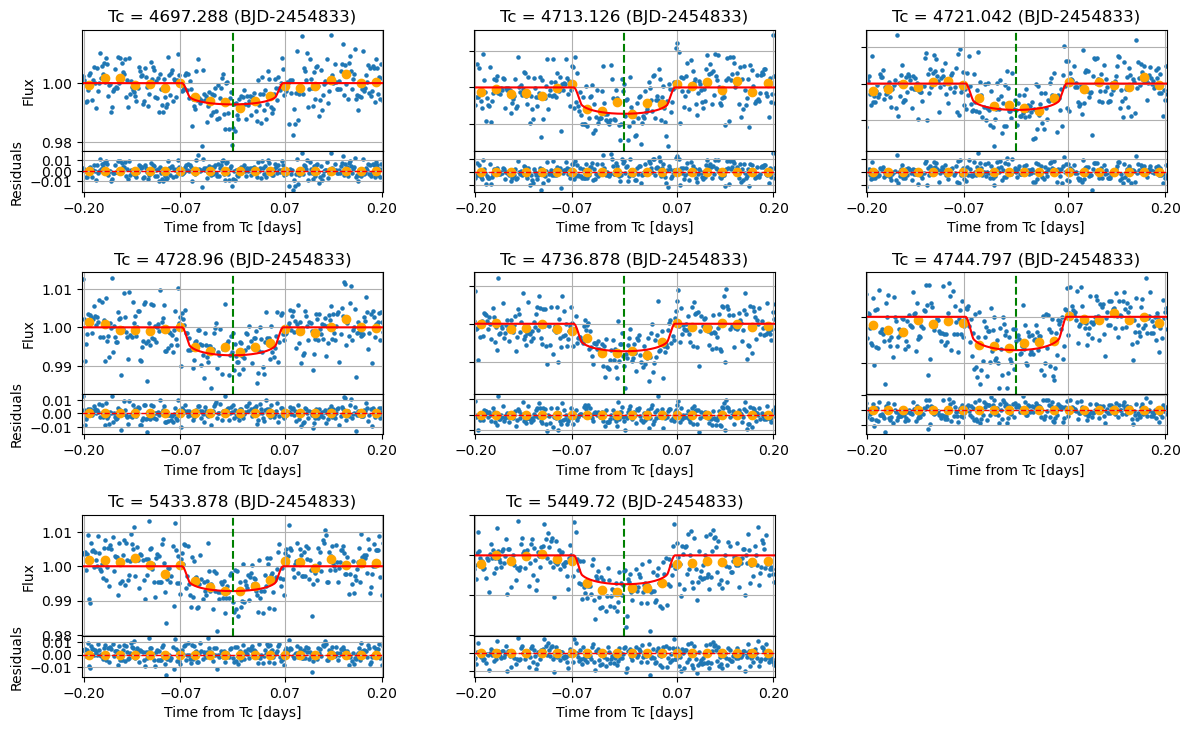

In [50]:
time= np.array(time)
tc_chi_b = np.array(tc_chi_b)
plot_transits(convert_time_t2p(time), flux, flux_err, convert_time_t2p(tc_chi_b), per_b, rp_b, b_b, T14_b, u1, u2, buffer=T14_b*1.5, offset=petigura_offset)


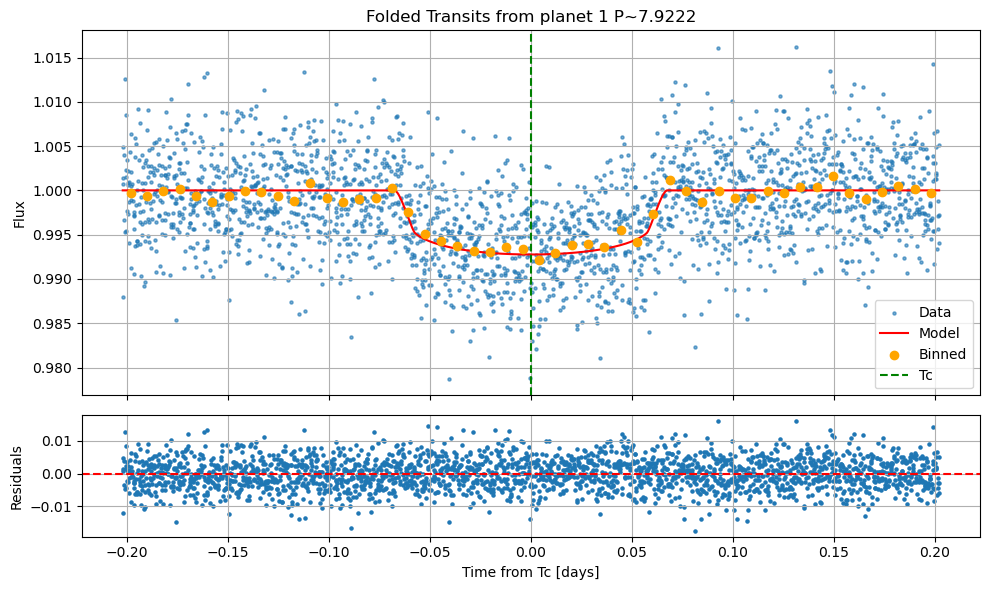

In [51]:
time= np.array(time)
tc_chi_b = np.array(tc_chi_b)
plot_folded_from_transits(convert_time_t2p(tc_chi_b), convert_time_t2p(time), flux, per_b, rp_b, b_b, T14_b, u1, u2, buffer=T14_b*1.5,
                              title=f'Folded Transits from planet 1 P~{per_b}')


# plot model at jnkep predicted times 

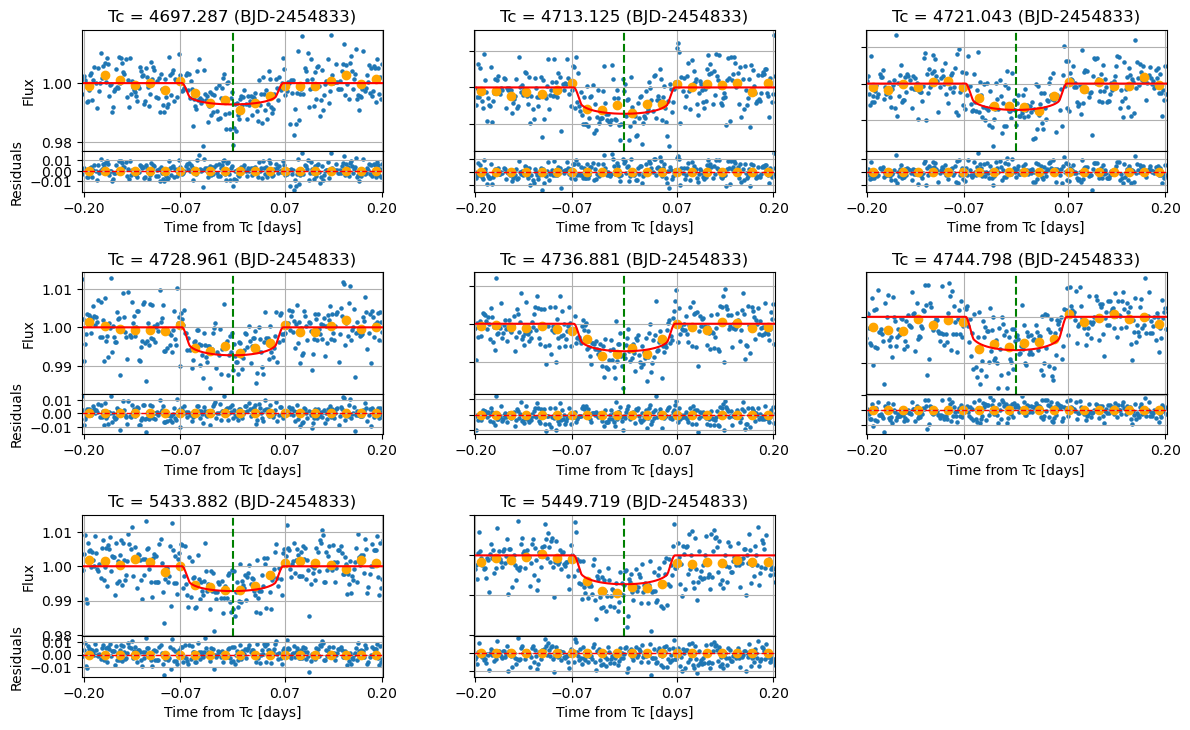

In [52]:
# plot model around jnkep predicted times 
time_pet = convert_time_t2p(time)
transit_guess_jnkep_b = np.array(transit_guess_jnkep_b)
transit_guess_jnkep_b_pet = convert_time_t2p(transit_guess_jnkep_b)
plot_transits(time_pet, flux, flux_err, transit_guess_jnkep_b_pet, per_b, rp_b, b_b, T14_b, u1, u2, buffer = T14_b*1.5, offset=petigura_offset)

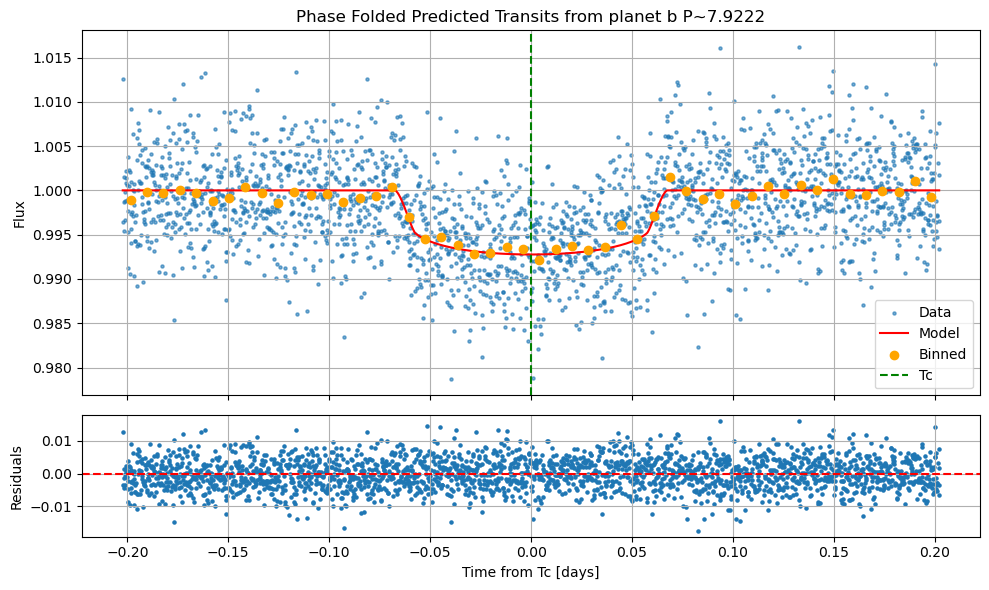

In [53]:
plot_folded_from_transits(transit_guess_jnkep_b_pet, time_pet, flux, per_b, rp_b, b_b, T14_b, u1, u2, buffer=T14_b*1.5,
                              title=f'Phase Folded Predicted Transits from planet b P~{per_b}')

In [54]:
### params from exoplanet archive
per_c = 11.8993
rp_c = 0.0458
T14_c = 3.823 * 0.0416667  # convert to days
b_c = 0.630

### params from Petigura et al 2020 for Kreidberg Batman
per_c = 11.8993
rp_c = 0.0458
a_c = semi_major_axis(per_c, M_star, R_star) # [stellar_radii]
inc_c = 91.1
ecc_c = 0.10 

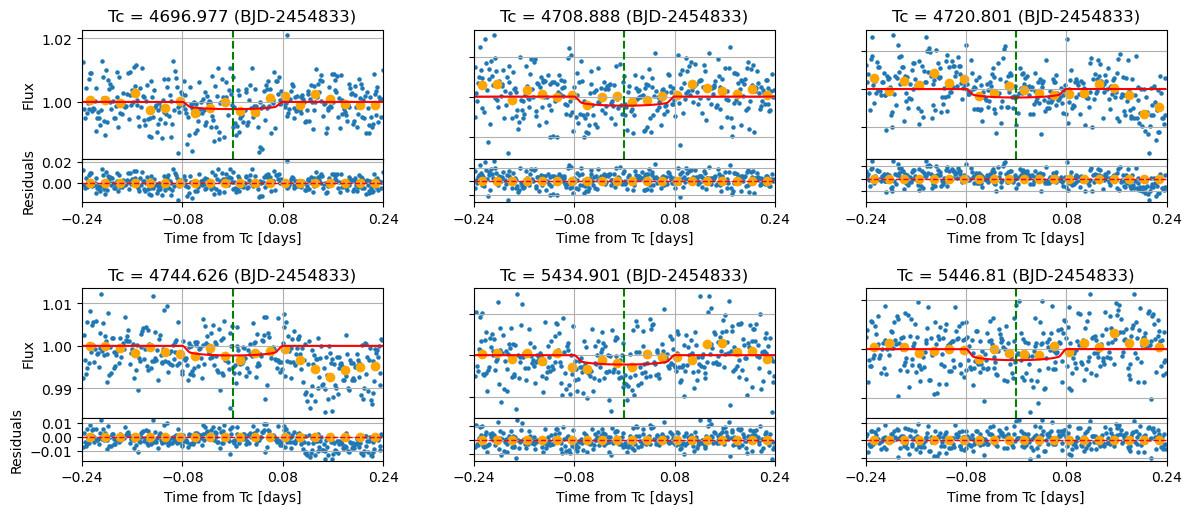

In [55]:
# plot model around jnkep predicted times 
time_pet = convert_time_t2p(time)
transit_guess_jnkep_c = np.array(transit_guess_jnkep_c)
transit_guess_jnkep_c_pet = convert_time_t2p(transit_guess_jnkep_c)
plot_transits(time_pet, flux, flux_err, transit_guess_jnkep_c_pet, per_c, rp_c, b_c, T14_c, u1, u2, buffer=T14_c*1.5, offset=petigura_offset)

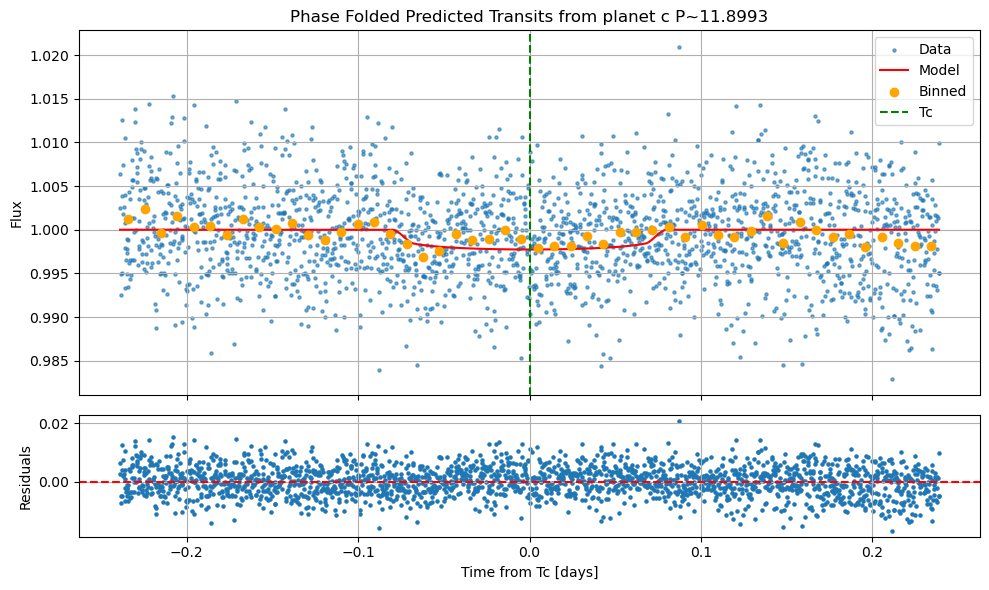

In [56]:
plot_folded_from_transits(transit_guess_jnkep_c_pet, time_pet, flux, per_c, rp_c, b_c, T14_c, u1, u2, buffer=T14_c*1.5,
                              title=f'Phase Folded Predicted Transits from planet c P~{per_c}')

# save data

In [58]:
#avg the errors   sig^2 = 0.5(sig1^2 + sig2^2)
err_tc_chi = []
for i in range(len(tc_errb_chi)):
    sig = np.sqrt(tc_errb_chi[i][0]**2 + tc_errb_chi[i][1]**2)
    err_tc_chi.append(sig)

transit_num = [0,2,3,4,5,6,93,95]

In [59]:
# Initialize empty list for storing results
results = []

# Loop through the transits and collect the data dynamically
for j in range(len(tc_chi_b)):
    transit = transit_num[j]
    transit_time = tc_chi_b[j]
    avg_error = err_tc_chi[j]
    
    # Create a dictionary for the current row
    row = {
        'Planet': 'k2-19b',
        'Transit': transit,
        'Tc(TESS)': transit_time,
        'Tc_err': avg_error,
        'Time Offset': 'BJD - 2454833',
    }

    # Append the row to the results list
    results.append(row)

# After the loop, create a DataFrame from the results list
tess_transit_data = pd.DataFrame(results)

# Save the DataFrame to a file named 'tess_times.csv'
# tess_transit_data.to_csv('tess_transit_data.csv', index=False)
tess_transit_data.to_csv('data/tess_transit_data.csv', index=False)

# Print the DataFrame to see the collected data
print(tess_transit_data)

   Planet  Transit     Tc(TESS)    Tc_err    Time Offset
0  k2-19b        0  2530.288226  0.004626  BJD - 2454833
1  k2-19b        2  2546.126226  0.002991  BJD - 2454833
2  k2-19b        3  2554.042123  0.002884  BJD - 2454833
3  k2-19b        4  2561.959723  0.003064  BJD - 2454833
4  k2-19b        5  2569.878272  0.004040  BJD - 2454833
5  k2-19b        6  2577.797223  0.002994  BJD - 2454833
6  k2-19b       93  3266.878296  0.003854  BJD - 2454833
7  k2-19b       95  3282.720298  0.002184  BJD - 2454833


In [ ]:
np.savetxt("data/transit_pred_jnkep_c.txt", transit_guess_jnkep_c)

In [ ]:
np.savetxt("data/transit_fit_jnkep_b.txt", tc_chi_b)